# VeriFact — Comparação entre Modelos de Embedding

Este notebook compara o desempenho do sistema **VeriFact** ao variar o modelo de embedding utilizado na etapa de recuperação de contexto (RAG), mantendo fixo o LLM judge (**DeepSeek**).

Os modelos avaliados são:
| Configuração | Modelo de Embedding |
|---|---|
| `BGE_Base_DeepSeek` | BAAI/bge-base |
| `BioClinical_ModernBert_DeepSeek` | BioClinicalBERT + ModernBERT |
| `Gte_Large_DeepSeek` | GTE Large |
| `Gte_Med_DeepSeek` | GTE Med |
| `MedEmbed_DeepSeek` | MedEmbed |
| `ModernBert_DeepSeek` | ModernBERT |

Para cada configuração são calculadas métricas de concordância com o *ground truth* humano do dataset **VeriFact-BHC**, nas duas condições de recuperação:
- **EHR Completo** (`reference_only_admission=False`)
- **Só Admissão** (`reference_only_admission=True`)

## 1. Configuração do Ambiente

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path
from sklearn.metrics import matthews_corrcoef, classification_report
from irrCAC.raw import CAC

## 2. Carregamento dos Dados

Carrega os veredictos de todas as configurações de embedding e o *ground truth* humano.
Cada subpasta de `experimento` corresponde a uma combinação `{EmbeddingModel}_DeepSeek`.

In [9]:
EXPERIMENT_DIR = Path('../data/experimento')
VERDICT_COLORS = {'Supported': '#2ecc71', 'Not Supported': '#e74c3c', 'Not Addressed': '#95a5a6'}
LABEL_ORDER = ['Supported', 'Not Supported', 'Not Addressed']

CONFIGS = {
    'BGE Base':              'BGE_Base_DeepSeek',
    'BioClinical ModernBert':'BioClinical_ModernBert_DeepSeek',
    'GTE Large':             'Gte_Large_DeepSeek',
    'GTE Med':            'Gte_Med_DeepSeek',
    'MedEmbed':              'MedEmbed_DeepSeek',
    'ModernBert':            'ModernBert_DeepSeek',
}

# Ground truth humano
props = pd.read_csv('../data/propositions.csv.gz')
human_verdicts = pd.read_csv('../data/human_verdicts.csv.gz')
top10_subjects = props['subject_id'].unique()[:10]
gt = (
    human_verdicts
    .merge(props[['proposition_id', 'subject_id']], on='proposition_id')
    .query('subject_id in @top10_subjects')[['proposition_id', 'human_gt']]
    .set_index('proposition_id')
)

# Carregar todos os veredictos
all_verdicts = {}
for label, folder in CONFIGS.items():
    path = EXPERIMENT_DIR / folder / 'score_reports' / 'verdicts.feather'
    all_verdicts[label] = pd.read_feather(path)
    print(f'{label:30s} — {len(all_verdicts[label])} veredictos')

BGE Base                       — 1996 veredictos
BioClinical ModernBert         — 1994 veredictos
GTE Large                      — 1995 veredictos
GTE Med                        — 1996 veredictos
MedEmbed                       — 1996 veredictos
ModernBert                     — 1996 veredictos


## 3. Cálculo das Métricas por Configuração

Para cada modelo de embedding e cada condição de recuperação, são calculados:
- **Gwet's AC1** — concordância entre VeriFact e o avaliador humano, com IC 95%
- **MCC** — Matthews Correlation Coefficient, robusto ao desbalanceamento de classes

In [10]:
rows = []
for label, verdicts in all_verdicts.items():
    for ref_only, cond in [(False, 'EHR Completo'), (True, 'Só Admissão')]:
        subset = verdicts[verdicts.reference_only_admission == ref_only][['verdict']].copy()
        merged = subset.join(gt.rename(columns={'human_gt': 'ground_truth'}), how='inner')
        if merged.empty:
            continue

        mcc = matthews_corrcoef(merged['ground_truth'], merged['verdict'])

        ratings = pd.DataFrame({'Human': merged['ground_truth'].values, 'VeriFact': merged['verdict'].values})
        ac1_res = CAC(ratings, categories=LABEL_ORDER).gwet()['est']

        rows.append({
            'Embedding': label,
            'Condição': cond,
            'n': len(merged),
            'Gwet AC1': ac1_res['coefficient_value'],
            'AC1 IC95 Lo': ac1_res['confidence_interval'][0],
            'AC1 IC95 Hi': ac1_res['confidence_interval'][1],
            'p-value': ac1_res['p_value'],
            'MCC': mcc,
        })

metrics_df = pd.DataFrame(rows)
metrics_df

,Embedding,Condição,n,Gwet AC1,AC1 IC95 Lo,AC1 IC95 Hi,p-value,MCC
0,BGE Base,EHR Completo,108,0.60352,0.48127,0.72577,2.220446e-16,0.068464
1,BGE Base,Só Admissão,108,0.64133,0.52465,0.75802,0.000000e+00,0.078887
2,BioClinical ModernBert,EHR Completo,107,0.62854,0.50894,0.74814,0.000000e+00,0.315858
3,BioClinical ModernBert,Só Admissão,107,0.69372,0.58426,0.80318,0.000000e+00,0.269035
4,GTE Large,EHR Completo,108,0.68460,0.57404,0.79516,0.000000e+00,0.262758
5,GTE Large,Só Admissão,108,0.71129,0.60558,0.81700,0.000000e+00,0.193242
6,GTE Med,EHR Completo,108,0.63555,0.51777,0.75334,0.000000e+00,0.240146
7,GTE Med,Só Admissão,108,0.71119,0.60537,0.81702,0.000000e+00,0.193165
8,MedEmbed,EHR Completo,108,0.66004,0.54552,0.77456,0.000000e+00,0.250947
9,MedEmbed,Só Admissão,108,0.70860,0.60188,0.81532,0.000000e+00,0.275567


## 4. Tabela Comparativa

Tabela resumida com Gwet's AC1 e MCC por modelo e condição, ordenada por AC1 decrescente.

In [11]:
pivot = metrics_df.pivot(index='Embedding', columns='Condição', values=['Gwet AC1', 'MCC'])
pivot.columns = [f'{m} — {c}' for m, c in pivot.columns]
pivot = pivot.sort_values('Gwet AC1 — Só Admissão', ascending=False)

display(pivot.style
    .format('{:.4f}')
    .background_gradient(cmap='RdYlGn', axis=0)
)

,Gwet AC1 — EHR Completo,Gwet AC1 — Só Admissão,MCC — EHR Completo,MCC — Só Admissão
Embedding,,,,
GTE Large,0.6846,0.7113,0.2628,0.1932
GTE Med,0.6355,0.7112,0.2401,0.1932
MedEmbed,0.6600,0.7086,0.2509,0.2756
ModernBert,0.6270,0.6992,0.1175,0.1873
BioClinical ModernBert,0.6285,0.6937,0.3159,0.2690
BGE Base,0.6035,0.6413,0.0685,0.0789


## 5. Gráfico de Barras — Gwet's AC1

Comparação visual do Gwet's AC1 entre modelos de embedding, com barras de erro representando o IC 95%.
As duas condições de recuperação são exibidas lado a lado para facilitar a comparação.

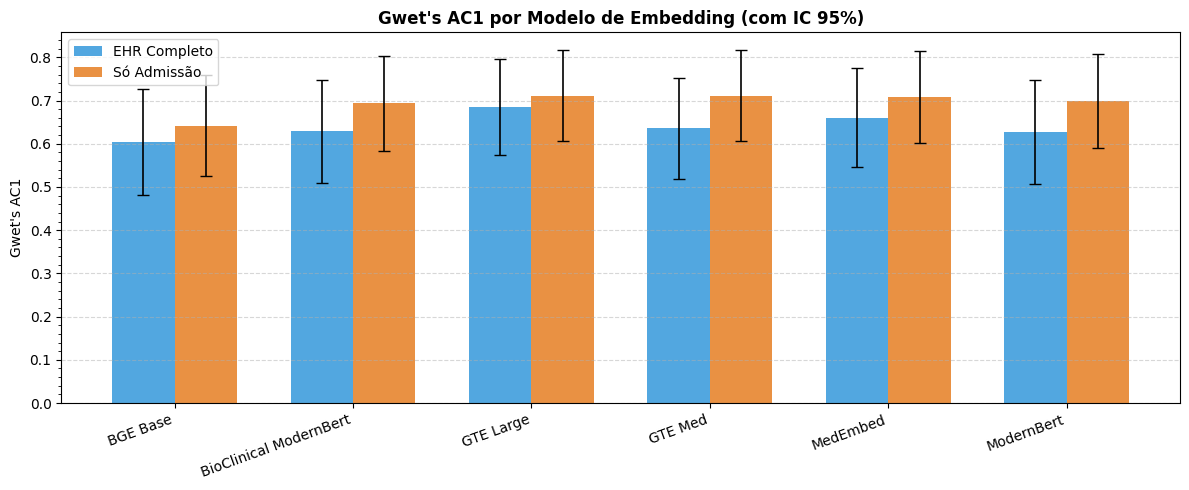

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))

conditions = ['EHR Completo', 'Só Admissão']
colors = ['#3498db', '#e67e22']
n_models = len(CONFIGS)
x = np.arange(n_models)
width = 0.35

for i, (cond, color) in enumerate(zip(conditions, colors)):
    sub = metrics_df[metrics_df['Condição'] == cond].set_index('Embedding').reindex(list(CONFIGS.keys()))
    err_lo = sub['Gwet AC1'] - sub['AC1 IC95 Lo']
    err_hi = sub['AC1 IC95 Hi'] - sub['Gwet AC1']
    ax.bar(x + i * width, sub['Gwet AC1'], width, label=cond, color=color, alpha=0.85,
           yerr=[err_lo, err_hi], capsize=4, error_kw={'elinewidth': 1.2})

ax.set_xticks(x + width / 2)
ax.set_xticklabels(list(CONFIGS.keys()), rotation=20, ha='right')
ax.set_ylabel("Gwet's AC1")
ax.set_title("Gwet's AC1 por Modelo de Embedding (com IC 95%)", fontweight='bold')
ax.legend()
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 6. Gráfico de Barras — MCC

Comparação do MCC entre modelos. Valores mais altos indicam melhor alinhamento com o *ground truth* humano considerando todas as classes simultaneamente.

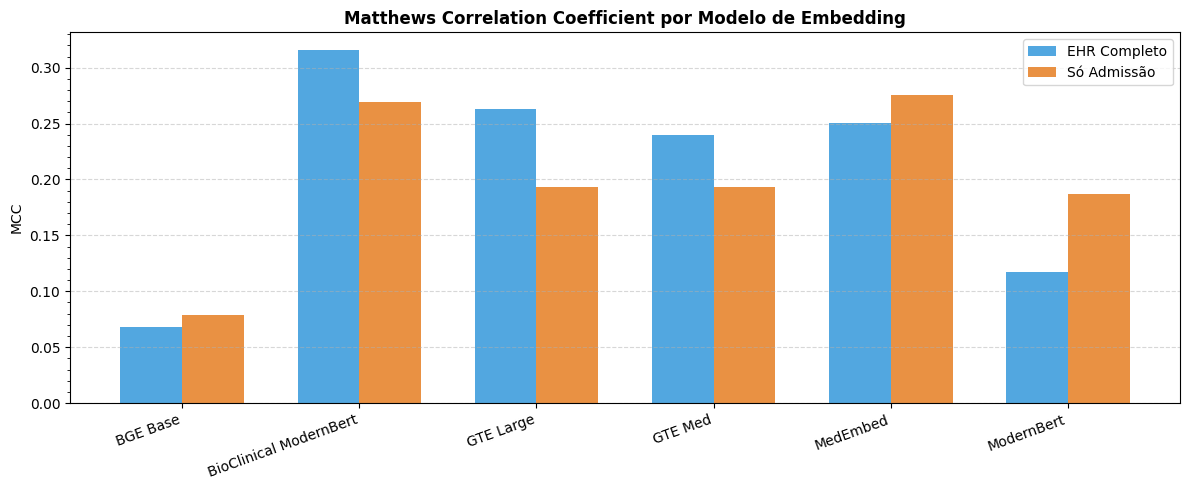

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))

for i, (cond, color) in enumerate(zip(conditions, colors)):
    sub = metrics_df[metrics_df['Condição'] == cond].set_index('Embedding').reindex(list(CONFIGS.keys()))
    ax.bar(x + i * width, sub['MCC'], width, label=cond, color=color, alpha=0.85)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(list(CONFIGS.keys()), rotation=20, ha='right')
ax.set_ylabel('MCC')
ax.set_title('Matthews Correlation Coefficient por Modelo de Embedding', fontweight='bold')
ax.legend()
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 7. Classification Report por Modelo

Relatório detalhado de precisão, recall e F1 por classe de veredicto para cada configuração de embedding, na condição **Só Admissão**.

In [14]:
for label, verdicts in all_verdicts.items():
    subset = verdicts[verdicts.reference_only_admission == True][['verdict']].copy()
    merged = subset.join(gt.rename(columns={'human_gt': 'ground_truth'}), how='inner')
    print(f'\n{"="*60}')
    print(f'  {label} — Só Admissão (n={len(merged)})')
    print(f'{"="*60}')
    print(classification_report(merged['ground_truth'], merged['verdict'], labels=LABEL_ORDER, zero_division=0))


  BGE Base — Só Admissão (n=108)
               precision    recall  f1-score   support

    Supported       0.96      0.71      0.82       103
Not Supported       0.04      0.33      0.08         3
Not Addressed       0.11      0.50      0.18         2

     accuracy                           0.69       108
    macro avg       0.37      0.51      0.36       108
 weighted avg       0.92      0.69      0.78       108


  BioClinical ModernBert — Só Admissão (n=107)
               precision    recall  f1-score   support

    Supported       0.99      0.74      0.84       102
Not Supported       0.13      1.00      0.23         3
Not Addressed       0.12      0.50      0.20         2

     accuracy                           0.74       107
    macro avg       0.41      0.75      0.42       107
 weighted avg       0.95      0.74      0.81       107


  GTE Large — Só Admissão (n=108)
               precision    recall  f1-score   support

    Supported       0.97      0.76      0.85       